In [1]:
import torch
from torch.optim import Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../data/cars.csv', index_col='Unnamed: 0')
df

,speed,dist
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16
6,9,10
7,10,18
8,10,26
9,10,34
10,11,17


In [ ]:
# w, b는 랜덤하게 지정
w = torch.empty( 1,requires_grad=True)
b = torch.empty( 1,requires_grad=True)
torch.nn.init.uniform_(w)
torch.nn.init.uniform_(b)

tensor([0.6002], requires_grad=True)

In [6]:
x = torch.FloatTensor( df['speed'].values )
y = torch.FloatTensor( df['dist'].values )

In [7]:
def cost():
    hx = w*x + b
    c = torch.mean( (hx-y)**2 )
    return c

In [8]:
optimizer = Adam( [w,b], lr=0.01 )
for epoch in range( 2000 ):
    c = cost()
    optimizer.zero_grad()
    c.backward()
    optimizer.step()
    print( 'cost:', c.item())

cost: 2338.32763671875
cost: 2322.70654296875
cost: 2307.145751953125
cost: 2291.647216796875
cost: 2276.211669921875
cost: 2260.839599609375
cost: 2245.532470703125
cost: 2230.291259765625
cost: 2215.11669921875
cost: 2200.00927734375
cost: 2184.970947265625
cost: 2170.001953125
cost: 2155.1025390625
cost: 2140.2744140625
cost: 2125.517822265625
cost: 2110.83349609375
cost: 2096.22216796875
cost: 2081.6845703125
cost: 2067.22119140625
cost: 2052.832763671875
cost: 2038.5194091796875
cost: 2024.2818603515625
cost: 2010.1207275390625
cost: 1996.036376953125
cost: 1982.0289306640625
cost: 1968.09912109375
cost: 1954.246826171875
cost: 1940.4730224609375
cost: 1926.7772216796875
cost: 1913.1597900390625
cost: 1899.62158203125
cost: 1886.1617431640625
cost: 1872.78125
cost: 1859.4798583984375
cost: 1846.2576904296875
cost: 1833.114501953125
cost: 1820.0509033203125
cost: 1807.06640625
cost: 1794.161376953125
cost: 1781.3355712890625
cost: 1768.5892333984375
cost: 1755.921875
cost: 1743.333

In [9]:
def hxFn( xd ):
    xd = torch.FloatTensor( xd )
    hx = w*xd + b
    print( type( hx ))
    return hx.detach().numpy()

In [10]:
hxFn( 15 )

<class 'torch.Tensor'>


array([-0.21703815, -0.21703815, -0.21703815, -0.21703815, -0.21703815,
       -0.21703815, -0.21703815, -0.21703815, -0.21703815, -0.21703815,
       -0.21703815, -0.21703815, -0.21703815, -0.21703815, -0.21703815],
      dtype=float32)

In [11]:
hxFn( [15,20] )

<class 'torch.Tensor'>


array([43.508915, 58.084232], dtype=float32)

In [12]:
pred = hxFn( x )
pred

<class 'torch.Tensor'>


array([11.443215, 11.443215, 20.188404, 20.188404, 23.10347 , 26.018532,
       28.933598, 28.933598, 28.933598, 31.84866 , 31.84866 , 34.76372 ,
       34.76372 , 34.76372 , 34.76372 , 37.678787, 37.678787, 37.678787,
       37.678787, 40.59385 , 40.59385 , 40.59385 , 40.59385 , 43.508915,
       43.508915, 43.508915, 46.423977, 46.423977, 49.33904 , 49.33904 ,
       49.33904 , 52.254105, 52.254105, 52.254105, 52.254105, 55.169167,
       55.169167, 55.169167, 58.084232, 58.084232, 58.084232, 58.084232,
       58.084232, 63.914356, 66.829414, 69.74448 , 69.74448 , 69.74448 ,
       69.74448 , 72.659546], dtype=float32)

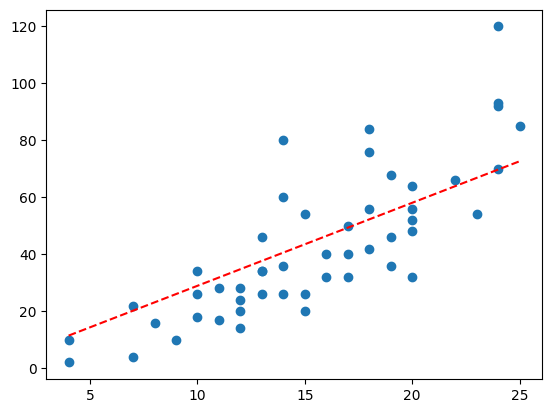

In [13]:
plt.scatter( x,y )
plt.plot( x, pred ,'r--')
plt.show()